# การวิเคราะห์ข้อมูลฝึกสอนสำหรับโมเดลจำแนกพืช (PlantCLEF 2026)

**รายวิชา:** การเตรียมข้อมูลฝึกสอน (Training Data)  
**หัวข้อโครงงาน:** การพัฒนาโมเดลจำแนกชนิดพืชในแปลงสำรวจ (PlantCLEF Multi-species Identification) ด้วยแนวทางแบบผสมผสาน (Hybrid: Pre-trained Feature Extraction + ML / Vector Search) เพื่อให้ใช้งานได้จริง

---

### วัตถุประสงค์
สมุดบันทึกนี้มีเป้าหมายเพื่อวิเคราะห์และทำความเข้าใจชุดข้อมูลฝึกสอนสำหรับการจำแนกชนิดพืช ทั้งในด้านวิธีการสุ่มตัวอย่าง คุณภาพของป้ายเฉลย ความไม่สมดุลของข้อมูล การแบ่งชุดข้อมูล และการเพิ่มความหลากหลายของรูปภาพ (Data Augmentation) เพื่อเตรียมข้อมูลให้พร้อมสำหรับโมเดลจำแนกพืชที่สามารถทำงานได้จริงบนทรัพยากรที่จำกัด

## 1. การสุ่มตัวอย่างข้อมูล (Sampling Analysis)

### 1.1 รูปแบบการเก็บข้อมูลแบบตามความสะดวก (Opportunistic Sampling)
ชุดข้อมูลภาพถ่ายพืชส่วนใหญ่ในโครงการ PlantCLEF รวบรวมผ่านแพลตฟอร์มพฤกษศาสตร์พลเมือง (Citizen Science) เช่น Pl@ntNet และ GBIF ซึ่งประชาชนและอาสาสมัครเป็นผู้ถ่ายภาพต้นไม้ที่พบเจอในชีวิตประจำวันแล้วอัปโหลดขึ้นสู่ระบบ
* **ข้อดี:** สามารถรวบรวมข้อมูลภาพถ่ายได้ปริมาณมหาศาล (มากกว่า 1.4 ล้านภาพ) จากหลากหลายพื้นที่ทั่วโลกอย่างรวดเร็ว โดยใช้งบประมาณน้อยกว่าการส่งนักวิจัยออกไปสำรวจแปลงพืชเองทั้งหมด
* **ข้อจำกัด:** ข้อมูลไม่ได้ผ่านการวางแผนเก็บตัวอย่างอย่างเป็นระบบ (Non-systematic Sampling) ทำให้จำนวนภาพของพืชแต่ละชนิดขึ้นอยู่กับความสนใจของผู้ถ่ายเป็นหลัก

### 1.2 อคติในข้อมูล (Sampling Biases)
1. **อคติด้านพื้นที่ (Spatial Bias):** ภาพถ่ายส่วนใหญ่กระจุกตัวอยู่ใกล้เขตเมือง สวนสาธารณะ หรือเส้นทางเดินป่าที่คนเข้าถึงง่าย ขณะที่พื้นที่ป่าลึกหรือพื้นที่ทุรกันดารมีข้อมูลน้อยมาก
2. **อคติด้านความสนใจของผู้ถ่าย (Taxonomic / Observer Bias):** คนทั่วไปมักชอบถ่ายภาพพืชที่มีดอกสวยงาม ผลเด่นชัด หรือพืชที่สะดุดตา ส่วนพืชกลุ่มหญ้า มอส หรือพืชที่ไม่มีดอกมักถูกละเลย
3. **อคติด้านอุปกรณ์และสภาพแวดล้อม (Temporal & Device Bias):** ภาพส่วนใหญ่ถ่ายในเวลากลางวันที่มีแดดดี และใช้โทรศัพท์มือถือหลากหลายรุ่น ทำให้คุณภาพของภาพและมุมมองมีความแตกต่างกันสูง

### 1.3 ผลกระทบต่อการกระจายตัวของข้อมูล
การเก็บข้อมูลแบบนี้ส่งผลให้การแจกแจงของข้อมูลมีลักษณะเป็น **หางยาว (Long-tail Distribution)** อย่างรุนแรง พืชที่พบบ่อยไม่กี่ชนิดจะมีภาพสะสมเป็นจำนวนมาก ในขณะที่พืชหายากส่วนใหญ่จะมีภาพเพียงไม่กี่ภาพ ทำให้โมเดลเรียนรู้ชนิดพืชได้ไม่เท่าเทียมกัน

## 2. การกำหนดเฉลยข้อมูล (Labeling Analysis)

### 2.1 แหล่งที่มาและกระบวนการเฉลยข้อมูล
ข้อมูลป้ายชื่อชนิดพืช (Labels) ได้มาจากกระบวนการระดมความคิดเห็นของผู้ใช้งาน (Crowdsourcing) บนแอปพลิเคชัน Pl@ntNet โดยผู้ใช้ร่วมกันเสนอชื่อชนิดพืชและให้คะแนนโหวต (Consensus Voting) หากมีความเห็นตรงกันในระดับความเชื่อมั่นที่กำหนด ระบบจึงจะยืนยันชื่อชนิดพืชนั้น

### 2.2 ปัญหาของป้ายเฉลยและการแก้ไขในระบบ
ในการใช้งานจริง ข้อมูลที่เก็บจากประชาชนมักพบปัญหาสำคัญ 3 ประการดังนี้:

| ปัญหาของป้ายเฉลย | ผลกระทบต่อการเรียนรู้ของโมเดล | แนวทางแก้ไขสำหรับระบบต้นแบบ |
| :--- | :--- | :--- |
| **1. ป้ายเฉลยผิดพลาด (Label Noise)** | ภาพถ่ายไม่ชัดเจน เบลอ หรือผู้ใช้ทั่วไปจำแนกผิดชนิด ทำให้โมเดลเรียนรู้ลักษณะของพืชผิดพลาด | ใช้การคัดกรองเฉพาะภาพที่ผ่านการตรวจสอบคะแนนโหวตจากผู้เชี่ยวชาญ และตัดภาพที่มีความขัดแย้งของคะแนนสูงออก |
| **2. ป้ายเฉลยไม่ละเอียด (Coarse / Ambiguous Labels)** | บางภาพระบุได้เพียงระดับสกุล (Genus) หรือวงศ์ (Family) แต่ไม่สามารถระบุชนิดย่อย (Species) ได้ | ออกแบบโมเดลให้ทำนายแบบลำดับขั้น (Hierarchical Classification) โดยเริ่มจากการทำนายวงศ์และสกุลก่อน แล้วจึงทำนายชนิดย่อย |
| **3. ข้อจำกัดด้านผู้เชี่ยวชาญ (Expert Bottleneck)** | พืชหายากหรือพืชที่มีลักษณะใกล้เคียงกันมาก ต้องอาศัยนักพฤกษศาสตร์มาตรวจเฉลย ซึ่งมีจำนวนจำกัด | ใช้ระบบ **Active Learning** เพื่อคัดเลือกเฉพาะภาพที่โมเดลไม่มั่นใจส่งต่อให้นักพฤกษศาสตร์ช่วยตรวจ ทำให้ประหยัดแรงงานและเวลาได้มาก |

## 3. การวิเคราะห์ระดับความไม่สมดุลของข้อมูล (Class Imbalance Analysis)

ในส่วนนี้ เราจะเขียนโค้ดเพื่อโหลดข้อมูลตาราง `PlantCLEF2024_single_plant_training_metadata.csv` มาคำนวณค่าสถิติวัดระดับความไม่สมดุล และสร้างกราฟแสดงการกระจายตัวของจำนวนภาพในแต่ละชนิดพืชและแต่ละอวัยวะพืช

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

metadata_path = find_file("PlantCLEF2024_single_plant_training_metadata.csv")
print("โหลดข้อมูลจาก:", metadata_path)

df = pd.read_csv(metadata_path, sep=";", usecols=["species_id", "organ"], low_memory=False)
print("โหลดข้อมูลเสร็จสิ้น จำนวนแถวทั้งหมด:", len(df))

โหลดข้อมูลจาก: PlantCLEF2024_single_plant_training_metadata.csv


โหลดข้อมูลเสร็จสิ้น จำนวนแถวทั้งหมด: 1408033


In [2]:
total_images = len(df)
num_classes = df["species_id"].nunique()
class_counts = df["species_id"].value_counts()

min_count = class_counts.min()
max_count = class_counts.max()
mean_count = class_counts.mean()
median_count = class_counts.median()
imbalance_ratio = max_count / min_count

print("=== สรุปผลการวัดระดับความไม่สมดุลของข้อมูล (Class Imbalance Metrics) ===")
print(f"จำนวนรูปภาพทั้งหมด: {total_images:,} ภาพ")
print(f"จำนวนสายพันธุ์พืช (Classes): {num_classes:,} สายพันธุ์")
print(f"จำนวนรูปภาพต่ำสุดของสายพันธุ์ที่พบน้อยที่สุด: {min_count} ภาพ")
print(f"จำนวนรูปภาพสูงสุดของสายพันธุ์ที่พบมากที่สุด: {max_count} ภาพ")
print(f"ค่าเฉลี่ยจำนวนรูปภาพต่อสายพันธุ์ (Mean): {mean_count:.2f} ภาพ")
print(f"ค่ามัธยฐานจำนวนรูปภาพต่อสายพันธุ์ (Median): {median_count:.2f} ภาพ")
print(f"อัตราส่วนความไม่สมดุล (Imbalance Ratio = Max/Min): {imbalance_ratio:.2f}")

=== สรุปผลการวัดระดับความไม่สมดุลของข้อมูล (Class Imbalance Metrics) ===
จำนวนรูปภาพทั้งหมด: 1,408,033 ภาพ
จำนวนสายพันธุ์พืช (Classes): 7,806 สายพันธุ์
จำนวนรูปภาพต่ำสุดของสายพันธุ์ที่พบน้อยที่สุด: 1 ภาพ
จำนวนรูปภาพสูงสุดของสายพันธุ์ที่พบมากที่สุด: 823 ภาพ
ค่าเฉลี่ยจำนวนรูปภาพต่อสายพันธุ์ (Mean): 180.38 ภาพ
ค่ามัธยฐานจำนวนรูปภาพต่อสายพันธุ์ (Median): 176.00 ภาพ
อัตราส่วนความไม่สมดุล (Imbalance Ratio = Max/Min): 823.00


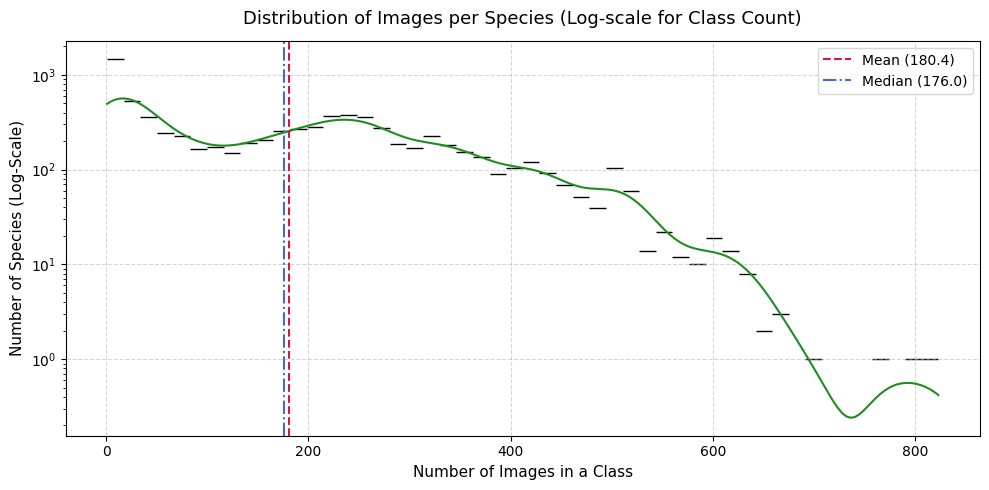

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(class_counts.values, bins=50, color="forestgreen", kde=True, log_scale=(False, True))
plt.title("Distribution of Images per Species (Log-scale for Class Count)", fontsize=13, pad=12)
plt.xlabel("Number of Images in a Class", fontsize=11)
plt.ylabel("Number of Species (Log-Scale)", fontsize=11)
plt.axvline(mean_count, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean ({mean_count:.1f})")
plt.axvline(median_count, color="royalblue", linestyle="-.", linewidth=1.5, label=f"Median ({median_count:.1f})")
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("species_distribution_plot.png", dpi=300)
plt.show()

/var/folders/1q/hwh4t8z51d37l52v_cb278sh0000gn/T/ipykernel_85180/1016758289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=organ_counts.index, y=organ_counts.values, palette="crest")


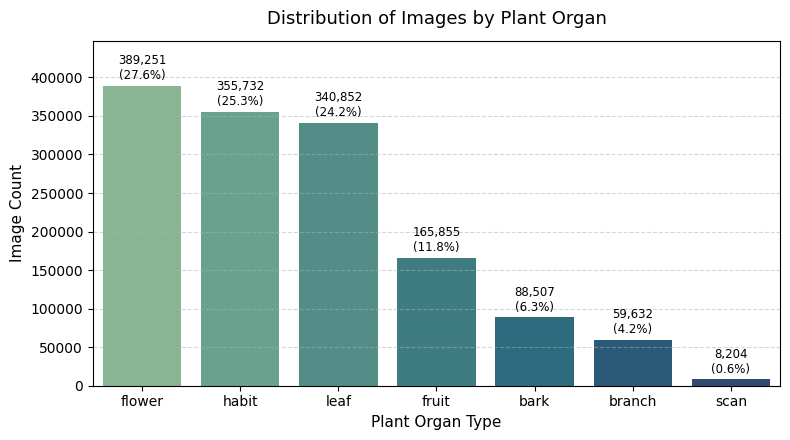

In [4]:
organ_counts = df["organ"].value_counts()
plt.figure(figsize=(8, 4.5))
sns.barplot(x=organ_counts.index, y=organ_counts.values, palette="crest")
plt.title("Distribution of Images by Plant Organ", fontsize=13, pad=12)
plt.xlabel("Plant Organ Type", fontsize=11)
plt.ylabel("Image Count", fontsize=11)
for i, val in enumerate(organ_counts.values):
    plt.text(i, val + 5000, f"{val:,}\n({val/total_images*100:.1f}%)", ha="center", va="bottom", fontsize=8.5)
plt.ylim(0, max(organ_counts.values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("organ_distribution_plot.png", dpi=300)
plt.show()

### 3.1 ผลกระทบจากความไม่สมดุลของข้อมูลต่อโมเดล
1. **โมเดลลำเอียงไปยังคลาสหลัก (Majority Class Bias):** ชนิดพืชที่มีข้อมูลมาก (สูงสุด 823 ภาพ) จะมีอิทธิพลต่อการปรับค่าน้ำหนักของโมเดล ทำให้โมเดลมักทายพืชเป็นชนิดยอดนิยมเสมอ
2. **ค่าความแม่นยำรวมหลอกตา (Deceptive Accuracy):** หากโมเดลทายเฉพาะพืชชนิดที่พบบ่อยได้ถูกต้อง ค่าความแม่นยำรวมอาจดูสูง แต่ค่าความสามารถในการค้นหาพืชชนิดหายาก (Recall ของ Minority Class) จะมีค่าต่ำมากหรือแทบเป็นศูนย์
3. **การสูญเสียข้อมูลสำคัญในการอนุรักษ์:** ในงานนิเวศวิทยา พืชหายากหรือพืชใกล้สูญพันธุ์เป็นข้อมูลที่สำคัญที่สุด หากระบบจำแนกไม่ได้จะทำให้การสำรวจความหลากหลายทางชีวภาพผิดพลาด

### 3.2 แนวทางแก้ไขปัญหาความไม่สมดุลของข้อมูล
1. **การปรับสมดุลตัวอย่าง (Resampling Techniques):**
   * *Random Over-sampling:* ทำซ้ำภาพของพืชชนิดที่มีภาพน้อยให้มีจำนวนใกล้เคียงกับค่าเฉลี่ย
   * *Random Under-sampling:* สุ่มลดจำนวนภาพของพืชชนิดที่มีภาพมากเกินไปเพื่อไม่ให้โมเดลจำเฉพาะชนิดนั้น
2. **การปรับค่าน้ำหนักการสูญเสีย (Loss-level Adjustment):**
   * ใช้เทคนิค *Class-weighted Loss* หรือ *Focal Loss* ซึ่งจะเพิ่มบทลงโทษเมื่อโมเดลทายพืชชนิดหายากผิดพลาด ทำให้โมเดลหันมาให้ความสนใจกับคลาสที่มีตัวอย่างน้อยมากขึ้น
3. **จุดเด่นของแนวทางแบบผสมผสาน (Hybrid Approach: DINOv2 + Vector Search):**
   * เวกเตอร์ตัวแทนภาพจาก DINOv2 เก็บเอกลักษณ์โครงสร้างพืชได้ดีมาก แม้พืชชนิดหายากจะมีภาพอ้างอิงเพียง 1-2 ภาพในฐานข้อมูล (Vector Store) เมื่อนำภาพแปลงสำรวจมาคำนวณความคล้ายคลึง (Cosine Similarity หรือ k-NN) ระบบก็ยังสามารถจับคู่และตรวจพบพืชหายากได้อย่างมีประสิทธิภาพโดยไม่ต้องเทรนโมเดลใหม่ทั้งหมด

In [5]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

train_part = pd.read_parquet(find_file("i_train.parquet"))
val_part = pd.read_parquet(find_file("i_val.parquet"))
test_part = pd.read_parquet(find_file("i_test.parquet"))
all_quadrats = pd.concat([train_part, val_part, test_part], ignore_index=True)

print("ข้อมูลชุดแปลงสำรวจภาพถ่ายพืช (Quadrat Images):")
print("จำนวนตัวอย่างทั้งหมด:", len(all_quadrats))
print("การแจกแจงของคลาสผู้ให้บริการข้อมูล (Provider):")
print(all_quadrats["provider"].value_counts())

train_df, test_df = train_test_split(
    all_quadrats, test_size=0.3, stratify=all_quadrats["provider"], random_state=42
)
val_df, final_test_df = train_test_split(
    test_df, test_size=0.5, stratify=test_df["provider"], random_state=42
)

print(f"\nขนาดหลังแบ่งข้อมูล (70/15/15): Train = {len(train_df)}, Val = {len(val_df)}, Test = {len(final_test_df)}")

X_train = train_df[["path"]]
y_train = train_df["provider"]

ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train, y_train)
print("\nผลการทำ Random Over-sampling บนข้อมูลฝึกสอน:")
print(y_over.value_counts())

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)
print("\nผลการทำ Random Under-sampling บนข้อมูลฝึกสอน:")
print(y_under.value_counts())

ข้อมูลชุดแปลงสำรวจภาพถ่ายพืช (Quadrat Images):
จำนวนตัวอย่างทั้งหมด: 2104
การแจกแจงของคลาสผู้ให้บริการข้อมูล (Provider):
provider
CBN        1476
LISAH       208
GUARDEN     201
RNNB        141
OPTMix       78
Name: count, dtype: int64

ขนาดหลังแบ่งข้อมูล (70/15/15): Train = 1472, Val = 316, Test = 316

ผลการทำ Random Over-sampling บนข้อมูลฝึกสอน:
provider
GUARDEN    1033
OPTMix     1033
CBN        1033
LISAH      1033
RNNB       1033
Name: count, dtype: int64

ผลการทำ Random Under-sampling บนข้อมูลฝึกสอน:
provider
CBN        54
GUARDEN    54
LISAH      54
OPTMix     54
RNNB       54
Name: count, dtype: int64


## 4. การเพิ่มขยายข้อมูลภาพ (Data Augmentation Analysis)

### 4.1 เทคนิคที่ควรใช้และมีประสิทธิภาพสูง
การเพิ่มความหลากหลายของภาพถ่ายพืชต้องทำอย่างระมัดระวังเพื่อไม่ให้ทำลายลักษณะทางพฤกษศาสตร์ของพืช:
* **การกลับภาพแนวนอนและแนวตั้ง (Horizontal / Vertical Flip):** เป็นธรรมชาติของใบ ดอก และต้นไม้ที่สามารถปรากฏในมุมมองใดก็ได้ในธรรมชาติ การกลับภาพจึงสมจริงและปลอดภัย
* **การหมุนภาพสุ่ม (Random Rotation):** ช่วยให้โมเดลจำแนกพืชได้แม้ภาพถ่ายจากกล้องมือถือจะเอียงหรือกลับหัว
* **การสุ่มครอบตัดและปรับขนาด (Random Resized Crop):** ช่วยให้โมเดลเรียนรู้ทั้งมุมมองใกล้ (Macro ซูมเห็นเกสรหรือขอบใบ) และมุมมองระยะไกล (เห็นทั้งต้น)
* **การปรับความสว่างและความคมชัดเล็กน้อย (Slight Brightness & Contrast):** จำลองสภาพแสงแดดจ้าหรือวันที่มีเมฆบังในธรรมชาติ

### 4.2 เทคนิคที่ไม่ควรใช้หรือควรหลีกเลี่ยง
* **การเปลี่ยนโทนสีอย่างรุนแรง (Extreme Hue Shift):** สีของดอกไม้และใบไม้เป็นลักษณะสำคัญในการจัดจำแนกชนิดพืช (Taxonomic Feature) หากเปลี่ยนสีดอกไม้จากสีม่วงเป็นสีแดง จะทำให้โมเดลสับสนและจำแนกผิดชนิด
* **การสร้างภาพใหม่ด้วย Generative AI:** โมเดลสร้างภาพอาจวาดรายละเอียดของใบ เกสร หรือเส้นใบที่ผิดไปจากความเป็นจริงตามหลักพฤกษศาสตร์ (Hallucination) ซึ่งส่งผลเสียอย่างยิ่งต่อการเรียนรู้ของโมเดล

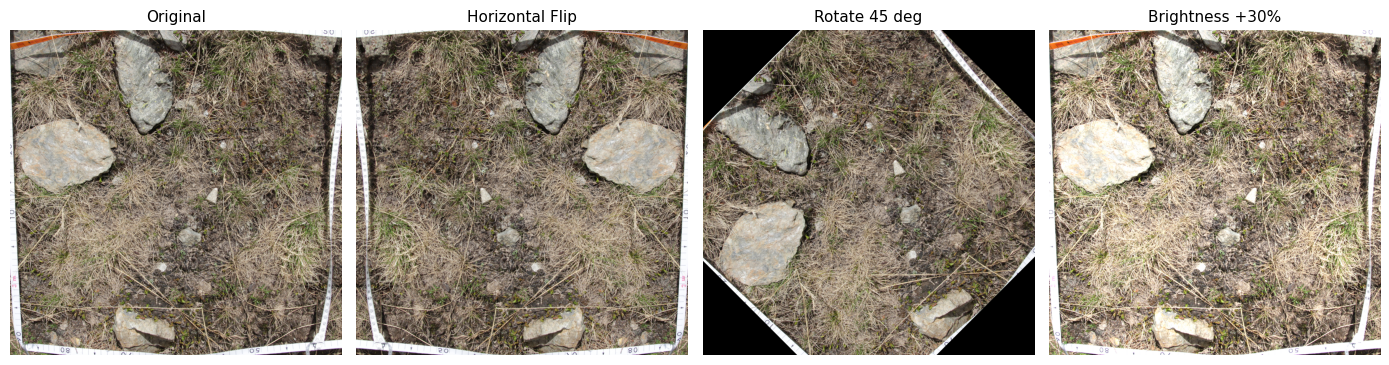

In [6]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

def find_file(name):
    candidates = [
        name,
        f"./{name}",
        f"../{name}",
        f"/Users/frankza/Downloads/plantclef-2026/{name}",
        f"/Users/frankza/Downloads/plantclef-2026/PlantCLEF2025_test_images/{name}",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return name

img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test_images")
if not os.path.exists(img_dir):
    img_dir = find_file("PlantCLEF2025_test_images/PlantCLEF2025_test")
if not os.path.exists(img_dir):
    img_dir = find_file("PlantCLEF2025_test_images")

img_files = [fn for fn in os.listdir(img_dir) if fn.lower().endswith(".jpg")]
sample_file = os.path.join(img_dir, img_files[0])
img = Image.open(sample_file)

flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
rotated = img.rotate(45)
bright = ImageEnhance.Brightness(img.copy()).enhance(1.3)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ["Original", "Horizontal Flip", "Rotate 45 deg", "Brightness +30%"]
images_list = [img, flipped, rotated, bright]

for ax, im, title in zip(axes, images_list, titles):
    ax.imshow(im)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. บทสรุปและเอกสารอ้างอิง (Summary & References)

### บทสรุปเชิงวิศวกรรมข้อมูล
ชุดข้อมูล PlantCLEF 2026 เป็นชุดข้อมูลภาพถ่ายธรรมชาติที่มีความซับซ้อนสูง ทั้งการเก็บข้อมูลแบบตามความสะดวก (Opportunistic Sampling) ที่ทำให้เกิดการกระจายตัวแบบหางยาว (Long-tail) และความไม่สมดุลของข้อมูลระหว่างชนิดพืชที่สูงถึง 823 เท่า  
ดังนั้น การออกแบบท่อส่งข้อมูลที่ดีจำเป็นต้องใช้การแบ่งข้อมูลแบบรักษาสัดส่วน (Stratified Splitting), การเพิ่มตัวอย่างและการปรับค่าน้ำหนัก Loss ให้เหมาะสม ร่วมกับการทำ Data Augmentation ที่คำนึงถึงลักษณะทางพฤกษศาสตร์ และการใช้แนวทางแบบผสมผสาน (Hybrid DINOv2 Feature Extraction + Vector Search) เพื่อให้สามารถจำแนกชนิดพืชทั้งชนิดที่พบบ่อยและพืชหายากได้อย่างมีประสิทธิภาพและใช้งานได้จริง

### เอกสารอ้างอิง
1. **Kaggle PlantCLEF 2026 Competition:** [https://www.kaggle.com/competitions/plantclef-2026](https://www.kaggle.com/competitions/plantclef-2026)
2. **Pl@ntNet Citizen Science Platform:** [https://plantnet.org/](https://plantnet.org/)
3. **Lin, T. Y. et al. (2017). "Focal Loss for Dense Object Detection."** *IEEE International Conference on Computer Vision (ICCV)*.
4. **Oquab, M. et al. (2023). "DINOv2: Learning Robust Visual Features without Supervision."** *Transactions on Machine Learning Research*.

---

**การมีส่วนร่วมของสมาชิกแต่ละคนในกลุ่ม (แต่ละคนทำอะไรบ้าง)**

6810405691 ปิยังกูร ปัสสาวะกัง : ร่วมกันคิดโปรเจกต์ ตรวจสอบ Data เช็คข้อมูล และ Export File

6810405887 ศิวภูมิ พรหมจรรย์ : ร่วมกันคิดโปรเจกต์ หา Data หาข้อมูลเพิ่มเติม และตรวจสอบความถูกต้อง

**การเปิดเผยการใช้งาน AI (AI Disclosure):** สมุดบันทึกนี้มีการใช้งานเครื่องมือปัญญาประดิษฐ์เพื่อช่วยเรียบเรียงคำอธิบายให้เข้าใจง่ายและเขียนโค้ด Python สำหรับวิเคราะห์ข้อมูลเชิงสถิติ โดยสมาชิกในกลุ่มได้ทำการทบทวน ตรวจสอบความถูกต้องของข้อมูลทั้งหมด และรันผลลัพธ์ด้วยตนเองเพื่อใช้ประกอบการส่งรายงาน